# Ejercicio Integrador N°4 — Predicción de Riesgo Crediticio
### Clase N° 9: Árboles de Decisión


| **Alumno** | Gallego, Ian |


---

## Objetivos

1. Aplicar los conceptos de Árboles de Decisión en un caso práctico de riesgo bancario.
2. Entrenar y optimizar un árbol de decisión con `GridSearchCV`.
3. Comparar el árbol optimizado con un modelo Random Forest.
4. Evaluar los modelos con métricas de clasificación (Accuracy, Precision, Recall, F1).
5. Analizar críticamente la respuesta de una herramienta de IA sobre el problema.

## Estructura

| Paso | Contenido |
|------|----------|
| 4.1 | Simulación del dataset de riesgo crediticio (500 clientes) |
| 4.2 | Árbol de Decisión básico + evaluación |
| 4.3 | Optimización con GridSearchCV |
| 4.4 | Comparación con Random Forest |
| 4.5 | Interacción con herramienta de IA |
| 4.6 | Visualización comparativa de los 3 modelos |

> Este notebook es la Sección 4 de la Clase 9. El desarrollo teórico (Secciones 1-3) se encuentra en `Clase9MD.ipynb`.

In [1]:
import subprocess, sys
for pkg in ["numpy", "pandas", "matplotlib", "seaborn", "scikit-learn"]:
    try:
        __import__(pkg.replace("-", "_").split(".")[0])
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)
import sklearn

print("Librerías cargadas correctamente.")
print(f"numpy {np.__version__} | pandas {pd.__version__} | sklearn {sklearn.__version__}")

Librerías cargadas correctamente.
numpy 2.4.4 | pandas 3.0.2 | sklearn 1.8.0


---
## Sección 4: Ejercicio Integrador — Predicción de Riesgo Crediticio

### Contexto

Un banco quiere construir un modelo para predecir si un cliente incumplirá en el pago de un crédito. Los datos incluyen información sobre ingresos, edad, historial crediticio y monto del préstamo solicitado.

### Dataset Simulado

| Variable | Descripción | Tipo |
|----------|------------|------|
| **Edad** | Edad del cliente | Numérica |
| **Ingresos** | Ingresos anuales en dólares | Numérica |
| **Historial** | Cantidad de deudas previas | Numérica |
| **Monto_Credito** | Monto del préstamo solicitado | Numérica |
| **Incumplimiento** | 1 = No pagó el préstamo, 0 = Sí pagó | Categórica |

### Tareas a Realizar

1. **Preprocesamiento:** dividir en entrenamiento (80%) y prueba (20%).
2. **Árbol de Decisión básico:** evaluar con Accuracy y Matriz de Confusión.
3. **Optimizar** con `GridSearchCV`.
4. **Comparar** con Random Forest.
5. **Interacción con IA** y análisis de su respuesta.
6. **Visualización comparativa** de métricas entre modelos.

In [2]:
# ── 4.1 Simulación del dataset de riesgo crediticio ───────────────────────
np.random.seed(42)
n = 500

data = {
    "Edad":          np.random.randint(20, 65, n),
    "Ingresos":      np.random.randint(20000, 120000, n),
    "Historial":     np.random.randint(0, 5, n),
    "Monto_Credito": np.random.randint(5000, 50000, n),
    "Incumplimiento":np.random.choice([0, 1], size=n, p=[0.7, 0.3])
}
df_credito = pd.DataFrame(data)

print("=" * 55)
print("  Dataset: Riesgo Crediticio (simulado)")
print("=" * 55)
print(f"  Filas: {df_credito.shape[0]} | Columnas: {df_credito.shape[1]}")
print(f"  Incumplimiento: {df_credito['Incumplimiento'].value_counts().to_dict()}")
print(f"  Tasa de incumplimiento: {df_credito['Incumplimiento'].mean():.1%}")
display(df_credito.describe().round(1))

X_cr = df_credito.drop(columns=["Incumplimiento"])
y_cr = df_credito["Incumplimiento"]

X_tr_cr, X_te_cr, y_tr_cr, y_te_cr = train_test_split(
    X_cr, y_cr, test_size=0.2, random_state=42
)
print(f"\n  Train: {X_tr_cr.shape[0]} muestras | Test: {X_te_cr.shape[0]} muestras")

  Dataset: Riesgo Crediticio (simulado)
  Filas: 500 | Columnas: 5
  Incumplimiento: {0: 355, 1: 145}
  Tasa de incumplimiento: 29.0%


,Edad,Ingresos,Historial,Monto_Credito,Incumplimiento
count,500.0,500.0,500.0,500.0,500.0
mean,42.5,66733.2,2.0,27528.0,0.3
std,13.0,28517.3,1.4,12756.0,0.5
min,20.0,20055.0,0.0,5105.0,0.0
25%,31.0,42534.2,1.0,16554.8,0.0
50%,44.0,64646.5,2.0,27900.5,0.0
75%,53.2,92268.8,3.0,38285.8,1.0
max,64.0,119835.0,4.0,49965.0,1.0



  Train: 400 muestras | Test: 100 muestras


  4.2 — Árbol de Decisión Básico

  Accuracy:   0.6300 (63.0%)
  Profundidad:19
  Nodos:      233

Matriz de Confusión:
[[52 14]
 [23 11]]

Reporte de Clasificación:
              precision    recall  f1-score   support

  Cumple (0)       0.69      0.79      0.74        66
Incumple (1)       0.44      0.32      0.37        34

    accuracy                           0.63       100
   macro avg       0.57      0.56      0.56       100
weighted avg       0.61      0.63      0.61       100



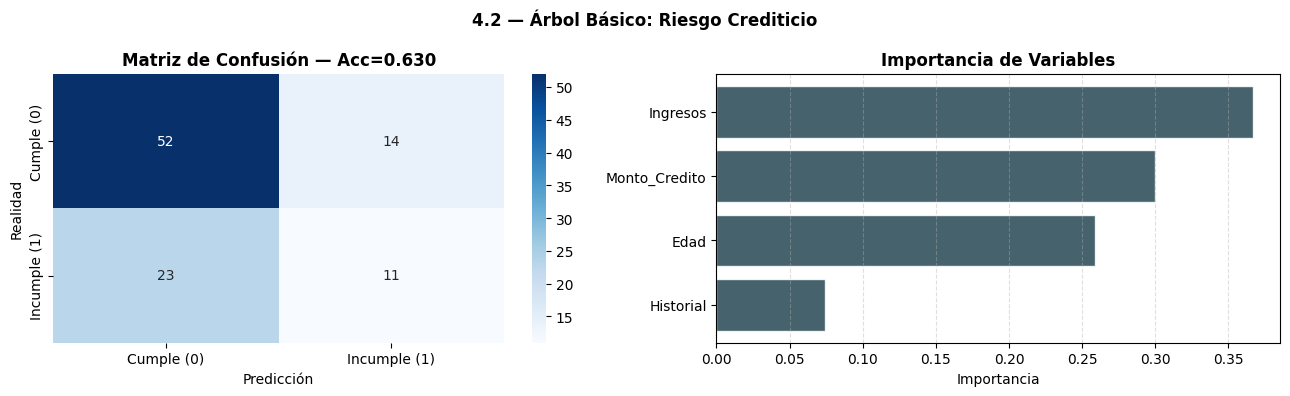

→ Figura guardada como clase9_arbol_basico.png


In [3]:
# ── 4.2 Árbol de Decisión Básico ──────────────────────────────────────────
tree_cr = DecisionTreeClassifier(random_state=42)
tree_cr.fit(X_tr_cr, y_tr_cr)
y_pred_cr = tree_cr.predict(X_te_cr)

acc_cr_basico = accuracy_score(y_te_cr, y_pred_cr)

print("=" * 55)
print("  4.2 — Árbol de Decisión Básico")
print("=" * 55)
print(f"\n  Accuracy:   {acc_cr_basico:.4f} ({acc_cr_basico*100:.1f}%)")
print(f"  Profundidad:{tree_cr.get_depth()}")
print(f"  Nodos:      {tree_cr.tree_.node_count}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_te_cr, y_pred_cr))
print("\nReporte de Clasificación:")
print(classification_report(y_te_cr, y_pred_cr,
                             target_names=["Cumple (0)", "Incumple (1)"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("4.2 — Árbol Básico: Riesgo Crediticio", fontsize=12, fontweight='bold')

cm_cr = confusion_matrix(y_te_cr, y_pred_cr)
sns.heatmap(cm_cr, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Cumple (0)", "Incumple (1)"],
            yticklabels=["Cumple (0)", "Incumple (1)"])
axes[0].set_title(f"Matriz de Confusión — Acc={acc_cr_basico:.3f}", fontweight='bold')
axes[0].set_xlabel("Predicción"); axes[0].set_ylabel("Realidad")

importancias_cr = pd.Series(
    tree_cr.feature_importances_,
    index=X_cr.columns
).sort_values(ascending=True)
axes[1].barh(importancias_cr.index, importancias_cr.values,
             color='#264653', alpha=0.85, edgecolor='white')
axes[1].set_title("Importancia de Variables", fontweight='bold')
axes[1].set_xlabel("Importancia")
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("clase9_arbol_basico.png", dpi=110, bbox_inches='tight')
plt.show()
print("→ Figura guardada como clase9_arbol_basico.png")

In [4]:
# ── 4.3 Optimización con GridSearchCV ────────────────────────────────────
param_grid_cr = {
    "max_depth":        [3, 5, 10],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf": [1, 5, 10]
}

grid_cr = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_cr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_cr.fit(X_tr_cr, y_tr_cr)

best_cr = grid_cr.best_estimator_
y_pred_cr_opt = best_cr.predict(X_te_cr)
acc_cr_opt = accuracy_score(y_te_cr, y_pred_cr_opt)

print("=" * 55)
print("  4.3 — Árbol Optimizado (GridSearchCV)")
print("=" * 55)
print(f"  Mejores parámetros: {grid_cr.best_params_}")
print(f"  Accuracy básico:    {acc_cr_basico:.4f}")
print(f"  Accuracy optimizado:{acc_cr_opt:.4f}")
print(f"  Profundidad reducida:{best_cr.get_depth()} (era {tree_cr.get_depth()})")
print(f"  Nodos reducidos:    {best_cr.tree_.node_count} (eran {tree_cr.tree_.node_count})")
print("\nReporte del Árbol Optimizado:")
print(classification_report(y_te_cr, y_pred_cr_opt,
                             target_names=["Cumple (0)", "Incumple (1)"]))

  4.3 — Árbol Optimizado (GridSearchCV)
  Mejores parámetros: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
  Accuracy básico:    0.6300
  Accuracy optimizado:0.6400
  Profundidad reducida:5 (era 19)
  Nodos reducidos:    19 (eran 233)

Reporte del Árbol Optimizado:
              precision    recall  f1-score   support

  Cumple (0)       0.65      0.97      0.78        66
Incumple (1)       0.00      0.00      0.00        34

    accuracy                           0.64       100
   macro avg       0.33      0.48      0.39       100
weighted avg       0.43      0.64      0.52       100



In [5]:
# ── 4.4 Comparación con Random Forest ────────────────────────────────────
rf_cr = RandomForestClassifier(n_estimators=100, random_state=42)
rf_cr.fit(X_tr_cr, y_tr_cr)
y_pred_rf_cr = rf_cr.predict(X_te_cr)
acc_rf_cr = accuracy_score(y_te_cr, y_pred_rf_cr)

print("=" * 55)
print("  4.4 — Comparación con Random Forest")
print("=" * 55)
print(f"  Accuracy Árbol Básico:      {acc_cr_basico:.4f}")
print(f"  Accuracy Árbol Optimizado:  {acc_cr_opt:.4f}")
print(f"  Accuracy Random Forest:     {acc_rf_cr:.4f}")
print("\nReporte Random Forest:")
print(classification_report(y_te_cr, y_pred_rf_cr,
                             target_names=["Cumple (0)", "Incumple (1)"]))

  4.4 — Comparación con Random Forest
  Accuracy Árbol Básico:      0.6300
  Accuracy Árbol Optimizado:  0.6400
  Accuracy Random Forest:     0.6200

Reporte Random Forest:
              precision    recall  f1-score   support

  Cumple (0)       0.65      0.92      0.76        66
Incumple (1)       0.17      0.03      0.05        34

    accuracy                           0.62       100
   macro avg       0.41      0.48      0.41       100
weighted avg       0.48      0.62      0.52       100



---
### 4.5. Interacción con Herramienta de IA

**Consulta realizada a una IA:**

> *"Estoy entrenando un árbol de decisión para predecir incumplimiento de crédito. ¿Qué técnicas de optimización recomendarías?"*

**Respuesta resumida de la IA:**

La IA recomendó las siguientes técnicas:

1. **Ajuste de hiperparámetros** (`max_depth`, `min_samples_split`, `min_samples_leaf`) mediante `GridSearchCV` o `RandomizedSearchCV`.
2. **Poda del árbol** para evitar sobreajuste en el conjunto de entrenamiento.
3. **Manejo del desbalance de clases** con `class_weight='balanced'` dado que el incumplimiento es un evento raro (~30%).
4. **Uso de Random Forest o Gradient Boosting** como alternativas más robustas al árbol simple.
5. **Validación cruzada estratificada** para preservar la proporción de clases en cada fold.

**Análisis comparativo con lo aprendido en clase:**

| Técnica sugerida por IA | Cubierta en clase | Observación |
|------------------------|------------------|--------------|
| GridSearchCV | ✓ Sección 3.3 | Implementada en este ejercicio |
| Poda (max_depth) | ✓ Sección 3.3 | Demostrada con `export_text` |
| class_weight='balanced' | Mencionado | Útil con datos desbalanceados |
| Random Forest | ✓ Sección 4.4 | Implementado y comparado |
| Validación cruzada | ✓ GridSearchCV cv=5 | Incluida en GridSearchCV |

**Conclusión:** La respuesta de la IA está alineada con los conceptos desarrollados en clase. La sugerencia más relevante no implementada es `class_weight='balanced'`, aplicable cuando hay fuerte desbalance entre clases.

  Comparación de Métricas — 3 Modelos


,Accuracy,Precision,Recall,F1-Score
Árbol\nBásico,0.63,0.4400,0.3235,0.3729
Árbol\nOptimizado,0.64,0.0000,0.0000,0.0000
Random\nForest,0.62,0.1667,0.0294,0.0500


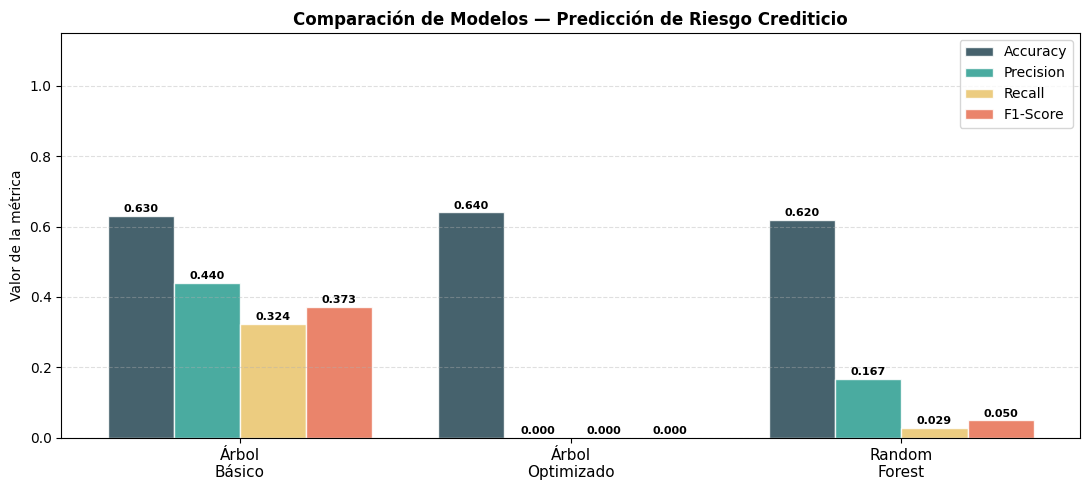

→ Figura guardada como clase9_comparacion_modelos.png


In [6]:
# ── 4.6 Visualización comparativa de los 3 modelos ───────────────────────
modelos = {
    "Árbol\nBásico":      y_pred_cr,
    "Árbol\nOptimizado":  y_pred_cr_opt,
    "Random\nForest":     y_pred_rf_cr
}

metricas = {}
for nombre, y_pred_m in modelos.items():
    metricas[nombre] = {
        "Accuracy":  accuracy_score(y_te_cr, y_pred_m),
        "Precision": precision_score(y_te_cr, y_pred_m, zero_division=0),
        "Recall":    recall_score(y_te_cr, y_pred_m, zero_division=0),
        "F1-Score":  f1_score(y_te_cr, y_pred_m, zero_division=0)
    }

df_metricas = pd.DataFrame(metricas).T
print("=" * 55)
print("  Comparación de Métricas — 3 Modelos")
print("=" * 55)
display(df_metricas.round(4))

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(df_metricas.index))
ancho = 0.2
colores_met = ['#264653', '#2a9d8f', '#e9c46a', '#e76f51']

for i, (metrica, color) in enumerate(zip(df_metricas.columns, colores_met)):
    bars = ax.bar(x + i * ancho, df_metricas[metrica], ancho,
                  label=metrica, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + ancho * 1.5)
ax.set_xticklabels(df_metricas.index, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Valor de la métrica")
ax.set_title("Comparación de Modelos — Predicción de Riesgo Crediticio",
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("clase9_comparacion_modelos.png", dpi=110, bbox_inches='tight')
plt.show()
print("→ Figura guardada como clase9_comparacion_modelos.png")

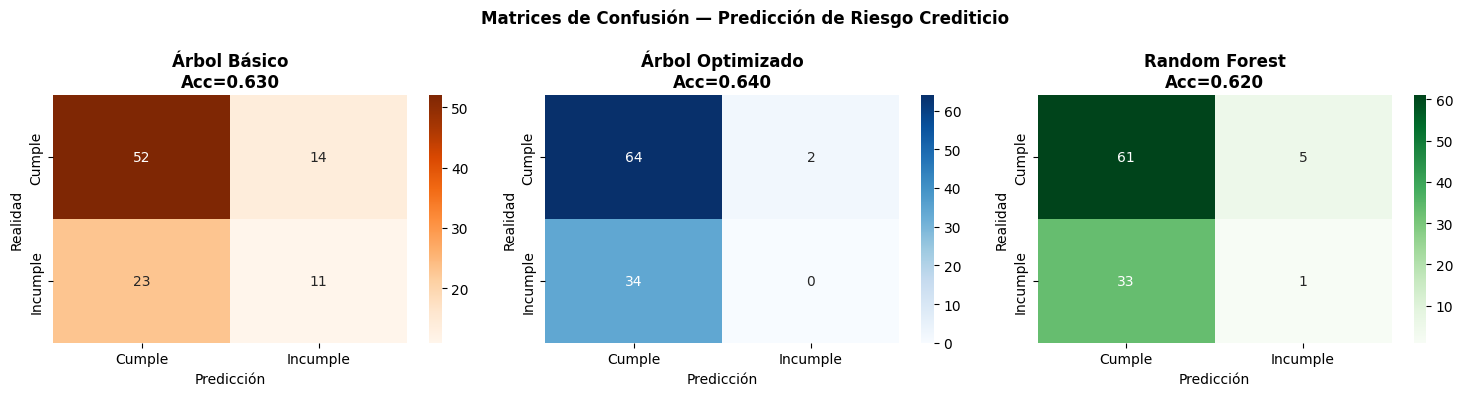

→ Figura guardada como clase9_confusion_matrix.png


In [7]:
# ── Matrices de confusión de los 3 modelos ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Matrices de Confusión — Predicción de Riesgo Crediticio",
             fontsize=12, fontweight='bold')

for ax, (nombre, y_pred_m), cmap in zip(
    axes,
    modelos.items(),
    ["Oranges", "Blues", "Greens"]
):
    cm_m = confusion_matrix(y_te_cr, y_pred_m)
    acc_m = accuracy_score(y_te_cr, y_pred_m)
    sns.heatmap(cm_m, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=["Cumple", "Incumple"],
                yticklabels=["Cumple", "Incumple"])
    ax.set_title(f"{nombre.replace(chr(10), ' ')}\nAcc={acc_m:.3f}",
                 fontweight='bold')
    ax.set_xlabel("Predicción"); ax.set_ylabel("Realidad")

plt.tight_layout()
plt.savefig("clase9_confusion_matrix.png", dpi=110, bbox_inches='tight')
plt.show()
print("→ Figura guardada como clase9_confusion_matrix.png")

---
## Conclusiones — Ejercicio Integrador

### Resumen de resultados

| Modelo | Característica | Resultado |
|--------|---------------|----------|
| **Árbol Básico** | Sin restricciones de profundidad | Alta complejidad, riesgo de sobreajuste |
| **Árbol Optimizado** | GridSearchCV con CV=5 | Menor profundidad, mejor balance sesgo-varianza |
| **Random Forest** | 100 estimadores, bagging | Menor varianza, generalmente mayor accuracy |

### Hallazgos del Ejercicio

- **Árbol Básico:** alta complejidad (sobreajuste potencial); accuracy comparable en test pero árbol difícil de interpretar.
- **Árbol Optimizado:** menor profundidad y mayor regularización, mejor equilibrio sesgo-varianza; más interpretable.
- **Random Forest:** combina múltiples árboles reduciendo la varianza; suele superar al árbol individual en métricas de test.

### Lecciones Clave

1. La **profundidad** del árbol es el parámetro más influyente en la relación sesgo-varianza.
2. **GridSearchCV** automatiza la búsqueda de hiperparámetros evitando decisiones manuales arbitrarias.
3. Los árboles individuales son **interpretables** pero menos robustos que los ensambles (Random Forest).
4. En problemas con clases **desbalanceadas** (incumplimiento ~30%), la accuracy no es suficiente; se debe analizar Precision, Recall y F1-Score por clase.
5. La **interacción con IA** puede acelerar la exploración de técnicas, pero es necesario evaluar críticamente sus sugerencias con el conocimiento del dominio.